<a href="https://colab.research.google.com/github/Rahma772/Praktikum-Pemodelan-Simulasi-dan-Optimasi/blob/main/RAHMAWATI_241061003_UTS_PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAMA : RAHMAWATI**

**NIM : 241061003**

**PRODI : SAINS DATA**

**MATKUL : PEMODELAN, SIMULASI DAN OPTIMASI**

**SOAL UTS PEMODELAN, SIMULASI DAN OPTIMASI**

Kerjakan soal di Google Colab dengan memberikan penjelasan di setiap point
1. Download data UTS melalui link berikut (Data). Import data ke dalam Google Colab. Ganti
nama variabel menjadi Y, X1, X2, X3 dan X4 (point: 5)
2. Lakukan pemodelan regresi berganda dengan Y sebagai variabel dependen, interpretasikan
hasil pemodelan. (point: 15)
3. Selidiki distribusi probabilitas disetiap variabel (point: 5)
4. Carilah nilai parameter dari setiap distribusi probabilitas di Y, X1, X2, X3 dan X4 (point: 15)
5. Simulasikan Y, X1, X2, X3 dan X4 menjadi 500 data sesuai dengan aturan (point 25)
6. Modelkan data hasil simulasi dengan Y sebagai variabel dependen, dan interpretasikan (point
25).
7. Bandingkan pemodelan hasil simulasi dan tanpa simulasi, berikan penjelasan mengenai hasil.
(point 10)

**Import Library yang akan digunakan**

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats


**Membaca dataset yang telah di upload**

In [50]:
df = pd.read_excel('/content/data soal UTS.xlsx')
df

,IPM (Y),Mayoritas Lulusan (X1),Harapan Lama Sekolah (X2),APS (X3),AHH (X4)
0,71.28,0,12.53,56.90,71.11
1,73.80,1,13.62,71.40,69.55
2,70.25,0,13.00,71.43,67.85
3,73.64,0,13.43,74.53,68.84
4,75.11,1,13.87,79.24,71.34
5,73.01,0,13.70,68.96,70.89
6,68.95,0,12.12,70.64,66.99
7,71.13,0,12.69,65.24,69.04
8,84.85,1,15.61,71.19,72.60
9,80.77,1,15.12,84.45,71.39


**Mengganti Nama Setiap Variabel**

In [51]:
df = df.rename(columns={
    'IPM (Y)': 'Y',
    'Mayoritas Lulusan (X1)': 'X1',
    'Harapan Lama Sekolah (X2)': 'X2',
    'APS (X3)': 'X3',
    'AHH (X4)': 'X4'
})
df.head()

,Y,X1,X2,X3,X4
0,71.28,0,12.53,56.90,71.11
1,73.80,1,13.62,71.40,69.55
2,70.25,0,13.00,71.43,67.85
3,73.64,0,13.43,74.53,68.84
4,75.11,1,13.87,79.24,71.34


**Melakukan Pemodelan Regresi Berganda dengan Y sebagai Variabel Dependen**

Hipotesis untuk regresi berganda:

H0 (Hipotesis nol): Tidak terdapat pengaruh yang signifikan antara X1, X2, X3, dan X4 terhadap Y.

H1 (Hipotesis alternatif): Terdapat pengaruh yang signifikan antara X1, X2, X3, dan X4 terhadap Y.

In [52]:
X = df[['X1','X2','X3','X4']]
Y = df['Y']

# Tambahkan konstanta
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     36.07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        02:14:12   Log-Likelihood:                -16.957
No. Observations:                  12   AIC:                             43.91
Df Residuals:                       7   BIC:                             46.34
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.9539     30.443      0.918      0.3


Berdasarkan hasil ols regression, dapat dilihat bahwa R-squarednya 0,954 yang dimana ini membuktikan model ini sangat baik dan variasi y dapat di jelaskan oleh X1,X2,X3,X4, kemudian untuk uji F yang signifikan  (p < 0,05) yang menandakan model ini layak digunakan, namunsecara uji parsial hanya X2 yang signifikan terhadap Y karena nilai koefisiennya sebesar 4,868 dan p-value sebesar 0,001 (< 0,05) dan meskipun tidak terdapat autokorelasi, terdapat indikasi kemungkinan multikolinearitas berdasarkan nilai condition number yang tinggi.


**Distribusi Probabilitas (PDF) Tiap Variabel**

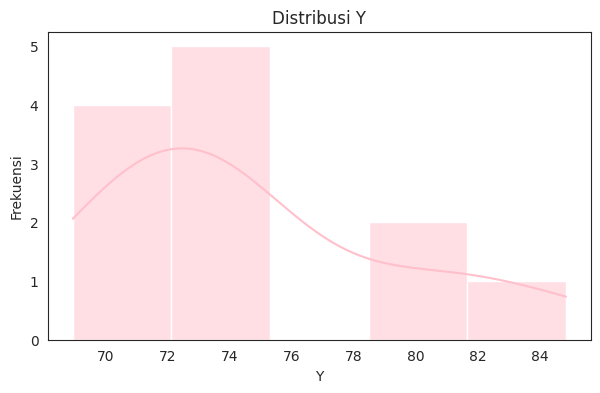

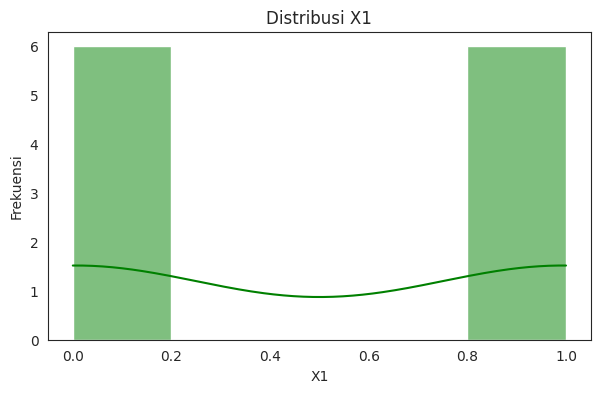

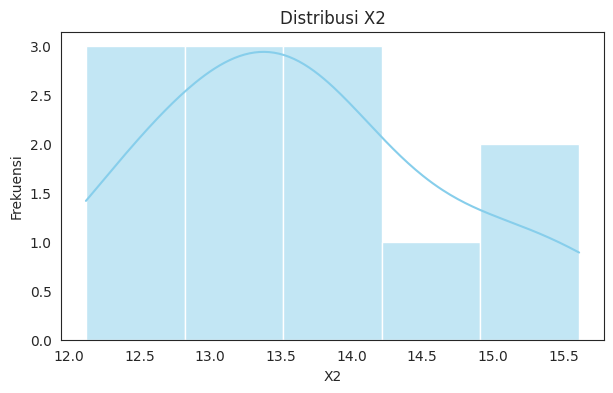

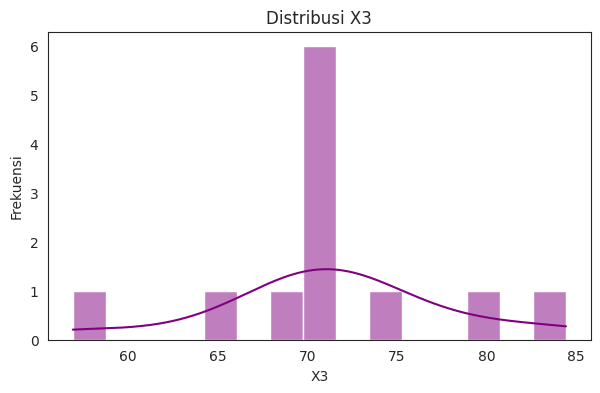

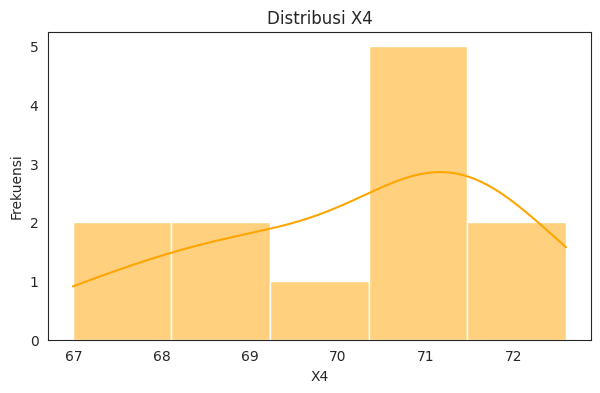

In [59]:
colors = ['pink', 'green', 'skyblue', 'purple', 'orange']
sns.set_style("white")
for i, col in enumerate(df.columns):
    plt.figure()
    sns.histplot(df[col], kde=True, color=colors[i])
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

**Nilai Parameter Setiap Variabel dari distribusi Probabilitas**

In [54]:
params = {}

for col in df.columns:
    mu, std = stats.norm.fit(df[col])
    params[col] = (mu, std)
    print(f'{col} -> mean = {mu:.4f}, std = {std:.4f}')

Y -> mean = 74.6983, std = 4.6218
X1 -> mean = 0.5000, std = 0.5000
X2 -> mean = 13.6367, std = 0.9954
X3 -> mean = 71.3400, std = 6.4356
X4 -> mean = 70.1983, std = 1.6422


**Membuat Simulasi Y, X1, X2, X3 dan X4 menjadi 500 data**

In [55]:
np.random.seed(42)

sim_data = pd.DataFrame()

for col in df.columns:
    mu, std = params[col]
    sim_data[col] = np.random.normal(mu, std, 500)

sim_data.head()

,Y,X1,X2,X3,X4
0,76.994027,0.963089,15.029574,76.349201,69.089578
1,74.059309,1.454708,14.557040,67.792803,69.961009
2,77.691794,-0.199284,13.696022,66.074420,68.897047
3,81.737412,0.781485,12.992711,71.318283,69.692609
4,73.616133,0.174679,14.331673,70.244764,67.088701


**Membuat Model dari Data Hasil Simulasi dengan Y sebagai Variabel Dependen**

In [56]:
X_sim = sim_data[['X1','X2','X3','X4']]
Y_sim = sim_data['Y']

X_sim = sm.add_constant(X_sim)

model_sim = sm.OLS(Y_sim, X_sim).fit()
print(model_sim.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.533
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.191
Time:                        02:14:13   Log-Likelihood:                -1461.8
No. Observations:                 500   AIC:                             2934.
Df Residuals:                     495   BIC:                             2955.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.7734     10.079      7.518      0.0

Berdasarkan hasil analisis regresi linear berganda yang telah dilakukan dengan metode OLS, nilai R-squared yang di peroleh hanya sebesar 0,012, artinya model yang telah di bangun hanya mampu menjelaskan 1,2% variasi pada variabel Y. Dari uji F, nilai signifikansi yang di dapatkan sebesar 0,191, sehingga dapat di simpulkan bahwa variabel X1,X2,X3, dan X4 secara bersama-sama tidak berpengaruh signifikan terhadap Y. Hasil yang sama juga di temukan pada uji parsial, di mana seluruh variabel menunjukkan nilai p-value di atas 0,05. Pada hasil diatas juga terbukti adanya indikasi multikolinearitas dari nilai condition number yang tinggi, meskipun tidak di temukan masalah autokorelasi. Secara keseluruhan, untuk nilai model ini masih perlu diperbaiki melalui pemilihan variabel yang lebih relevan dan bagus.

**Perbandingan Pemodelan Hasil Simulasi dan tanpa Simulasi**

In [57]:
print("=== MODEL DATA ASLI ===")
print(model.summary())

print("\n=== MODEL DATA SIMULASI ===")
print(model_sim.summary())

=== MODEL DATA ASLI ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     36.07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        02:14:13   Log-Likelihood:                -16.957
No. Observations:                  12   AIC:                             43.91
Df Residuals:                       7   BIC:                             46.34
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.9539     30

 Berdasarkan hasil analisis menunjukkan bahwa model data asli memiliki kinerja yang sangat baik dengan R-squared sebesar 0,954 dan uji F yang signifikan (p < 0,05), sehingga variabel independen secara bersama-sama mampu menjelaskan variabel dependen Y, meskipun secara parsial hanya X2 yang signifikan. Sebaliknya, model data simulasi memiliki kinerja yang sangat lemah dengan R-squared sebesar 0,012 dan uji F yang tidak signifikan (p > 0,05), sehingga variabel independen tidak mampu menjelaskan Y baik secara simultan maupun parsial. Dengan demikian, model data asli jauh lebih baik dibandingkan model data simulasi dalam menjelaskan variabel dependen.
